# Predicting Price Moves with News Sentiment
## 📊 Task 1: Exploratory Data Analysis (EDA) on Financial News
#### **Goals:**
 - Understand headline characteristics
 - Identify key publishers
 - Analyze article publication trends
 - Visualize common topics in news headlines

### 1. Setup and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import os

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bereket\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


### 2. Load the Dataset

In [4]:
df = pd.read_csv('../data/raw_analyst_ratings.csv')

### 3. Basic Dataset Inspection

In [5]:
print("Dataset Info:")
df.info()
print("\nFirst 5 Rows:")
display(df.head())
print("\nMissing Values:")
display(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB

First 5 Rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



Missing Values:


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

### 4. Descriptive Statistics

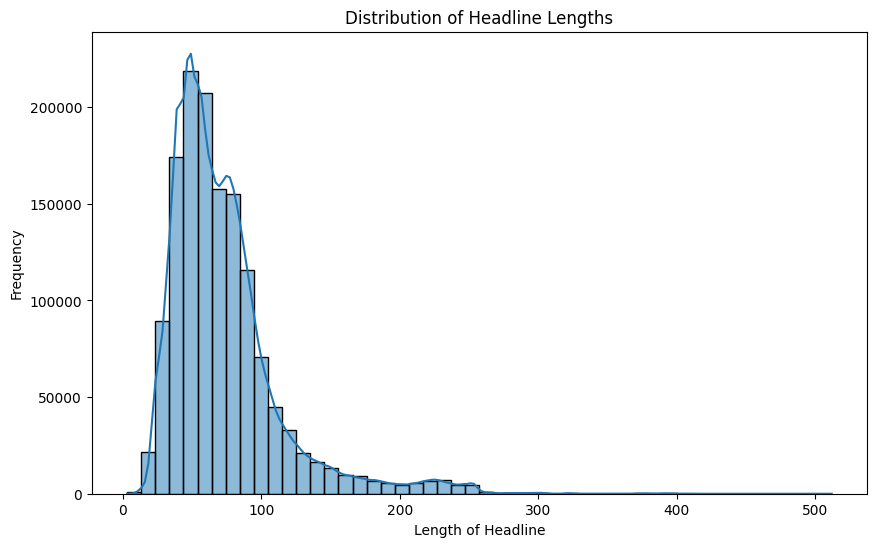

In [6]:
# 4.1 Headline Length Analysis
df['headline_length'] = df['headline'].astype(str).apply(len)
plt.figure(figsize=(10,6))
sns.histplot(df['headline_length'], bins=50, kde=True)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Length of Headline")
plt.ylabel("Frequency")
plt.show()

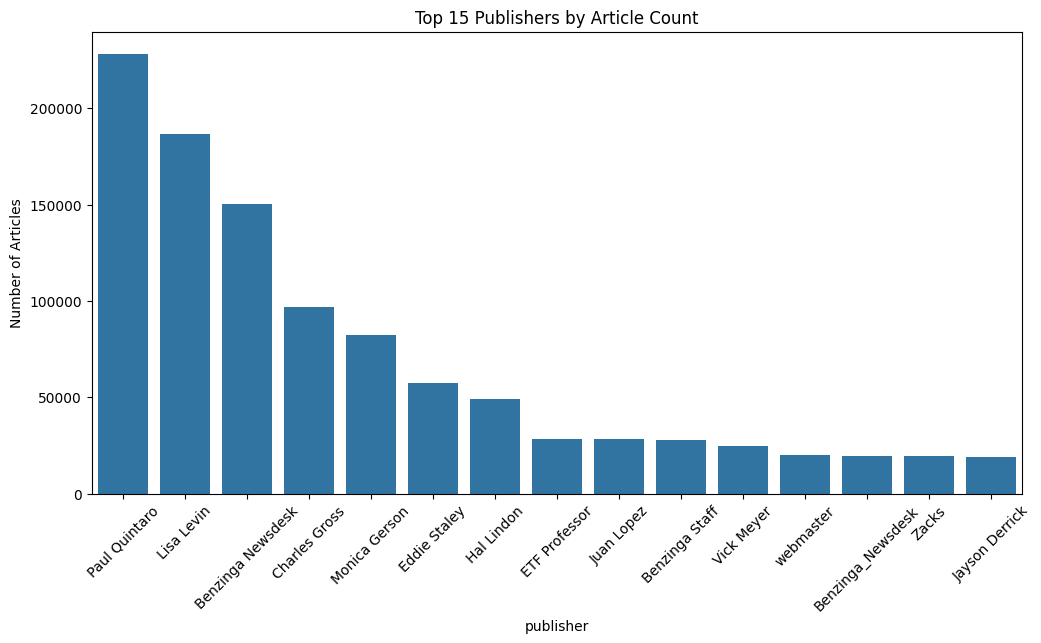

In [7]:
# 4.2 Article Count by Publisher
publisher_counts = df['publisher'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=publisher_counts.index[:15], y=publisher_counts.values[:15])
plt.xticks(rotation=45)
plt.title("Top 15 Publishers by Article Count")
plt.ylabel("Number of Articles")
plt.show()

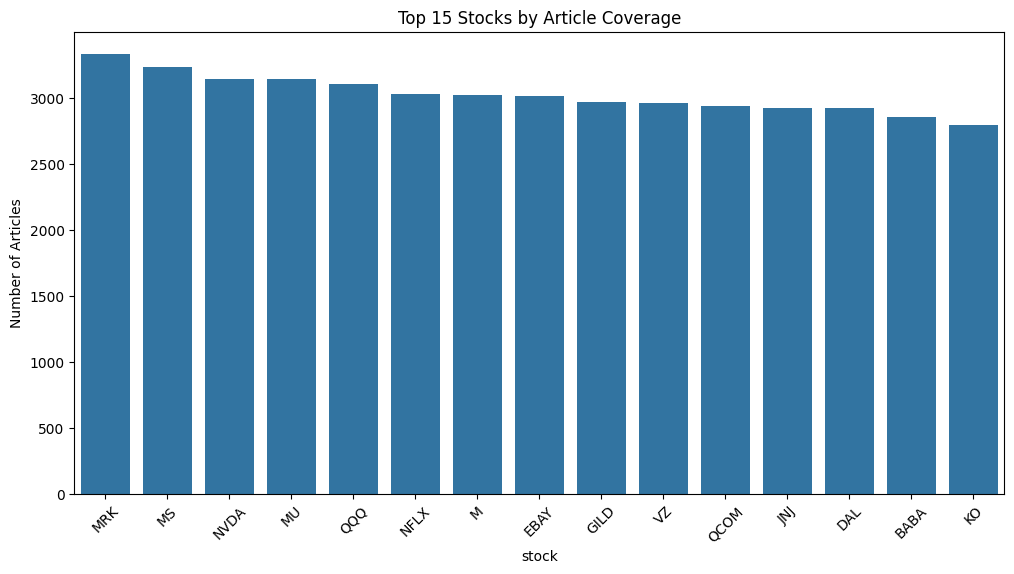

In [8]:
# 4.3 Article Count by Stock
stock_counts = df['stock'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=stock_counts.index[:15], y=stock_counts.values[:15])
plt.xticks(rotation=45)
plt.title("Top 15 Stocks by Article Coverage")
plt.ylabel("Number of Articles")
plt.show()

### 5. Time-Based Analysis

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [11]:
df = df.dropna(subset=['date'])
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.date

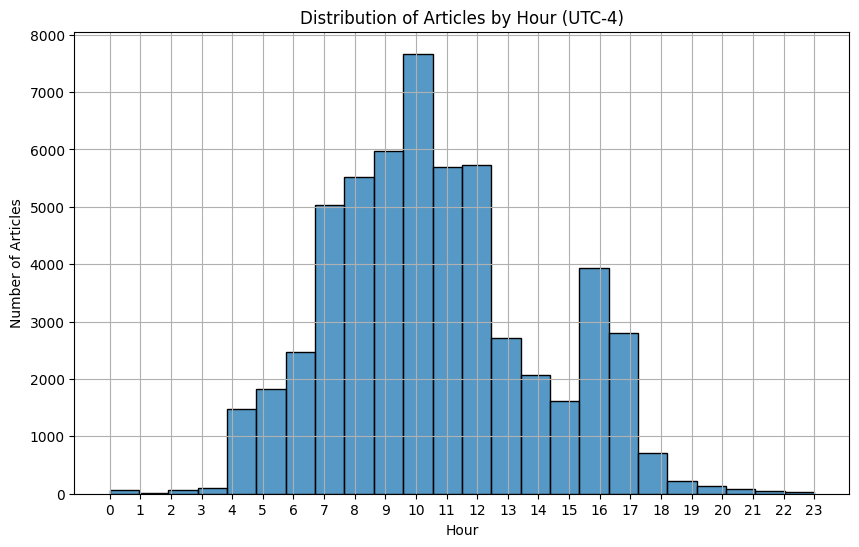

In [12]:
# 5.1 Articles by Hour of Day
plt.figure(figsize=(10,6))
sns.histplot(df['hour'], bins=24)
plt.title("Distribution of Articles by Hour (UTC-4)")
plt.xlabel("Hour")
plt.ylabel("Number of Articles")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

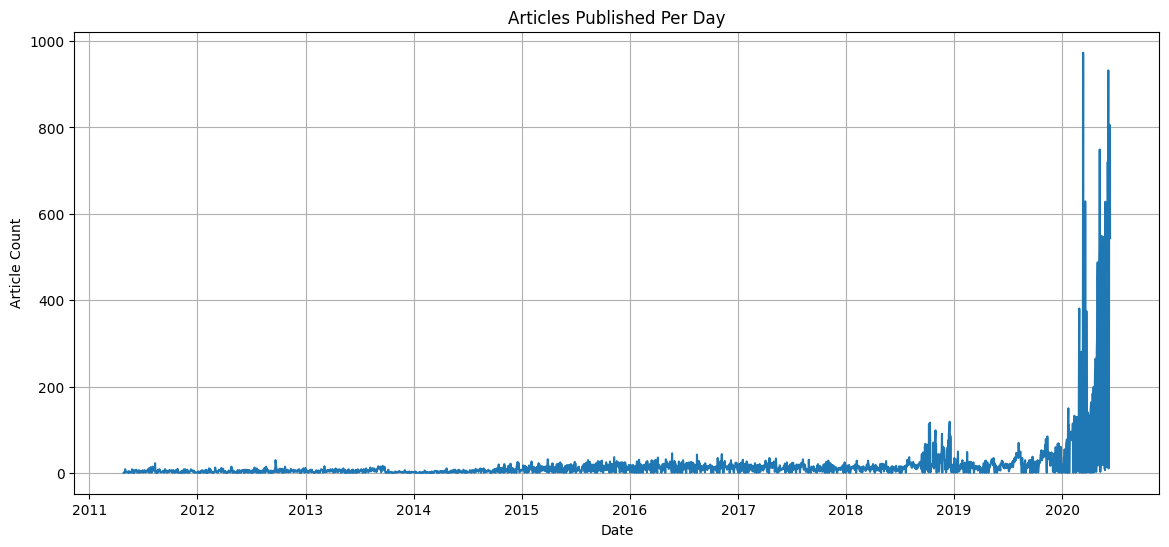

In [13]:
# 5.2 Articles Over Time (Daily)
df_daily = df.groupby('day').size()
plt.figure(figsize=(14,6))
df_daily.plot()
plt.title("Articles Published Per Day")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.grid(True)
plt.show()

### 6. Text Analysis - TF-IDF & Word Cloud

In [14]:
stop_words = stopwords.words('english')
df_clean = df.dropna(subset=['headline'])

In [15]:
vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, stop_words=stop_words, max_features=100)
tfidf_matrix = vectorizer.fit_transform(df_clean['headline'])

feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1
tfidf_df = pd.DataFrame({'word': feature_names, 'score': tfidf_scores})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False)

In [16]:
# Show top 20 keywords
print("Top 20 TF-IDF Keywords:")
display(tfidf_df.head(20))

Top 20 TF-IDF Keywords:


,word,score
85,stocks,3796.903632
96,week,3064.793067
5,52,2885.230472
82,shares,2534.329313
42,hit,2381.373745
34,etfs,2267.040511
50,market,2162.541589
65,price,2030.854830
86,target,1918.536952
89,trading,1796.360365


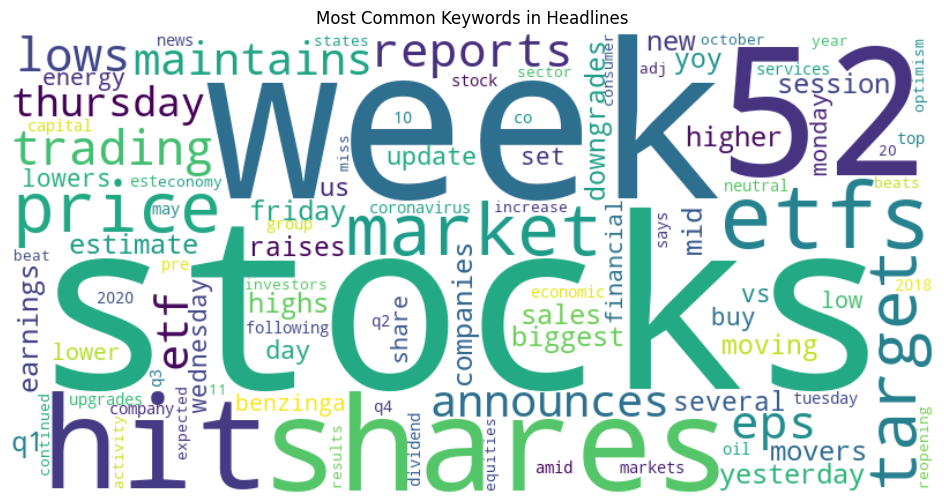

In [17]:
# Word Cloud
word_freqs = dict(zip(tfidf_df['word'], tfidf_df['score']))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freqs)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Keywords in Headlines")
plt.show()